In [1]:
import fastf1 as ff1
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from matplotlib.collections import LineCollection

%matplotlib widget

In [ ]:
session = ff1.get_session(2025, 23, "Q")
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (611.82 MB) C:\Users\Vitor\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api       

In [3]:
lap = session.laps.pick_fastest()
tel = lap.get_telemetry()

In [5]:
tel

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2021-07-03 13:52:43.255,0 days 01:07:16.840000,,429.534722,0 days 00:00:00,10709.562512,293.625001,8,100.0,False,12,interpolation,0.093493,0.000022,OnTrack,1193.471541,-1182.730471,7214.980785
3,2021-07-03 13:52:43.300,0 days 01:07:16.885000,,429.534722,0 days 00:00:00.045000,10718.000000,294.000000,8,100.0,False,12,pos,3.783333,0.000878,OnTrack,1159.000000,-1192.000000,7215.000000
4,2021-07-03 13:52:43.520,0 days 01:07:17.105000,,429.534722,0 days 00:00:00.265000,10757.416667,296.750000,8,100.0,False,12,pos,21.924825,0.005090,OnTrack,985.000000,-1239.000000,7215.000000
5,2021-07-03 13:52:43.540,0 days 01:07:17.125000,77,429.534722,0 days 00:00:00.285000,10761.000000,297.000000,8,100.0,False,12,car,23.583333,0.005475,OnTrack,969.040430,-1243.341187,7214.939667
6,2021-07-03 13:52:43.740,0 days 01:07:17.325000,77,421.145833,0 days 00:00:00.485000,10851.833333,299.500000,8,100.0,False,12,pos,40.244841,0.009344,OnTrack,809.000000,-1287.000000,7214.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,2021-07-03 13:53:46.540,0 days 01:08:20.125000,77,408.156667,0 days 00:01:03.285000,11640.000000,287.000000,7,100.0,False,12,car,4268.278889,0.990976,OnTrack,1533.009173,-1091.374912,7215.524579
549,2021-07-03 13:53:46.681,0 days 01:08:20.266000,77,403.339169,0 days 00:01:03.426000,11712.849967,288.762499,7,100.0,False,12,pos,4279.614223,0.993608,OnTrack,1425.000000,-1120.000000,7215.000000
550,2021-07-03 13:53:46.780,0 days 01:08:20.365000,77,399.956667,0 days 00:01:03.525000,11764.000000,290.000000,7,100.0,False,12,car,4287.612222,0.995465,OnTrack,1357.829129,-1138.523365,7214.927715
551,2021-07-03 13:53:46.901,0 days 01:08:20.486000,77,399.956667,0 days 00:01:03.646000,11770.554163,291.512499,7,100.0,False,12,pos,4297.434742,0.997745,OnTrack,1277.000000,-1161.000000,7215.000000


In [6]:
x = np.array(tel["X"].values)
y = np.array(tel["Y"].values)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
gear = tel["nGear"].to_numpy().astype(float)

In [8]:
cmap = colormaps["Paired"]
lc_comp = LineCollection(segments, norm=plt.Normalize(1, cmap.N+1), cmap=cmap)
lc_comp.set_array(gear)
lc_comp.set_linewidth(4)

In [11]:
plt.gca().add_collection(lc_comp)
plt.axis('equal')
plt.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)

title = plt.suptitle(
    f"Fastest Lap Gear Shift Visualization\n"
    f"{lap['Driver']} - {session.event['EventName']} {session.event.year}"
)

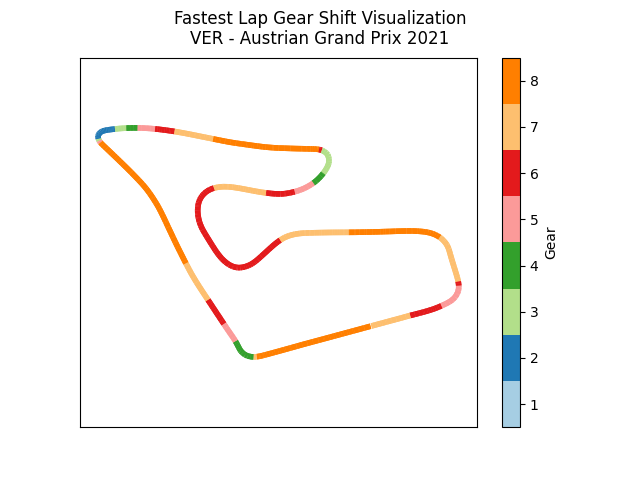

In [12]:
cbar = plt.colorbar(mappable=lc_comp, label="Gear", boundaries=np.arange(1, 10))
cbar.set_ticks(np.arange(1.5, 9.5))
cbar.set_ticklabels(np.arange(1, 9))

plt.show()